## Deterministic forecast example

We will illustrate here how to generate a deterministic forecast based on alredy downloaded forecast and hindcast data.
The process involves the following:
- using postprocessing function to restructure downloaded forecast data into the lead time-oriented structure
- bias-correcting hindcast and forecast
- processing the bias-corrected data "by hand" to generate deterministic forecast that includes:
    - calculating mean of the forecast ensemble for all lead times
    - calculating climatological mean of observations for each forecast period
    - calculating forecast anomalies - absolute, relative and percent anomaly
    - plotting resulting forecast maps - forecasted value, historical climatology, absolute anomaly, relative anomaly and anomaly expressed as percent of normal value.


In [1]:
#loading libraries
import xarray as xr
from matplotlib import pyplot as plt
import numpy as np
import pandas as pd
import geopandas as gpd
import cartopy.crs as ccrs
from acacia_s2s_toolkit.postprocess import postprocess_forecast, get_example_data
from acacia_s2s_toolkit.bias_correction import biascorrection_simple_qqmapping, biascorrection_meanvariance

## Getting some data to work with

In [2]:
#this is the data directory - you can change it as it suits you
data_dir="./data"

# this will load example data used in this notebook
# data are available at https://web.csag.uct.ac.za:~wolski/acacia/toolkit/
# comment this line if you want to work with your own data - 
# you will then have to define a file with observational data, and have 
# forecast and hindcast data for given initialization date downloaded to
# the data_dir

get_example_data(data_dir)

file already exists locally ./data/PRCPTOT_day_CHC_CHIRPS-2.0-0p25_merged.nc
file already exists locally ./data/tp_ECMWF_20260301_madagascar_hc.nc
file already exists locally ./data/tp_ECMWF_20260301_madagascar_fc.nc
file already exists locally ./data/madagascar.geojson


True

## Defining parameters for postprocessing

In [3]:
# defining what you want to process - i.e. forecast date, domain and observed dataset

# nominal forecast date is defined here. 
# This notebook uses example data for this date only
# example data are downloaded by a function get_example_data() called above

nominal_date="2026-03-01"
#target domain
target_domain="madagascar"
#forecast variable
fcst_var="tp"
#foreast model
fcst_model="ECMWF"

#this is file with observational data. It is gridded and covers the period of Jan 1981-March 2026
obs_file=f"{data_dir}/PRCPTOT_day_CHC_CHIRPS-2.0-0p25_merged.nc"

#we have to provide the name of the variable stored in the obs_file
obs_var="PRCPTOT"

# this is a file with vector data showing the boundaries of the domain - will be used in plotting only
domain_shape_file=f"{data_dir}/madagascar.geojson"

# data will be aggregated into blocks of this size - "5D" is a Pandas expression of temporal base and stands for 5 days
# if you want differently sized blocks - just change it into, say "7D"
agg_window="5D"

#and this defines how data will be aggreagated over the block - in this case it will be a sum of daily values
agg_method="sum"

# this defines regridding parameters for matching the obs and forecast grids. 
# it assumes obs grid is finer, so fine_to_coarse will give forecast grid, coarse_to_fine will give obs grid
# raise_if_missing will stop processing if the spatial overlap between obs and forecast grids of less than fractional 
# threshold
grid_alignment_kwargs=dict(
    direction="fine_to_coarse",
    method="conservative",
    raise_if_missing=True,
    threshold=0.9
)

# this defines time alignment parameter for matching the obs and hindcast time series. 
# raise_if_missing will stop processing if any of the hindcast days are not covered by observations 
time_alignment_kwargs={"raise_if_missing":True}

## postprocessing forecast and hindcast

In [4]:
# calling the preprocessing wrapper
hindcast_lt,forecast_lt,obs_lt=postprocess_forecast(
    nominal_date=nominal_date,
    download_dir=data_dir,
    target_domain=target_domain,
    fcst_var=fcst_var,
    fcst_model=fcst_model,
    agg_window=agg_window,
    agg_method=agg_method,
    obs_file=obs_file,
    obs_var=obs_var,
    grid_alignment_kwargs=grid_alignment_kwargs,
    time_alignment_kwargs=time_alignment_kwargs,
    verbose=False
)

logging is False
nominal forecast date: 2026-03-01
download dir: ./data
domain: madagascar
model: ECMWF
forecast variable: tp
aggregation window: 5D
observed file: ./data/PRCPTOT_day_CHC_CHIRPS-2.0-0p25_merged.nc
observed variable: PRCPTOT
postprocessing done


## Applying bias correction

In [6]:
#We will use q-q mapping bias correction
forecast_bc,hindcast_bc=biascorrection_simple_qqmapping(forecast_lt, hindcast_lt, obs_lt)

# making sure units are right - this should be implemented within the postprocessing function, but isn't at the time, so this is an ugly makeshift fix
forecast_bc.attrs["units"]="mm"
hindcast_bc.attrs["units"]="mm"


## Deriving deterministic forecast

In [7]:
# Deterministic forecast will simply be the ensemble mean
forecast_det=forecast_bc.mean("member")

#historical climatology will simply be mean across all initialization dates
obs_clim=obs_lt.mean("init_date")

#absolute anomaly will be a difference between forecast value and climatology:
forecast_absanom=forecast_det-obs_clim

#relative anomaly will be absolute anomaly expressed as percent of the climatological value
# this anomaly will have a negative value if forecast is for less than the climatological value

# we have to make sure obs_clim does not have 0, because it if does - relative anomaly is meaningless
obs_clim_clean=obs_clim.where(obs_clim>5)

forecast_relanom=forecast_absanom/obs_clim_clean*100

#we need to change the units of relative anomaly - they are no longer mm, it will be %
forecast_relanom.attrs["units"]="%"

#percent normal anomaly is forecast value expressed as percent of the climatological value
# this anomaly will always have positive values, with 100% being equal to climatology
forecast_percanom=forecast_det/obs_clim_clean*100

#we need to change the units of relative anomaly - they are no longer mm, it will be %
forecast_percanom.attrs["units"]="% of normal"


## Plotting forecast maps

Text(0.5, 0.98, 'Deterministic forecast (ensemble median) issued on 2026-03-01\n5 day total rainfall')

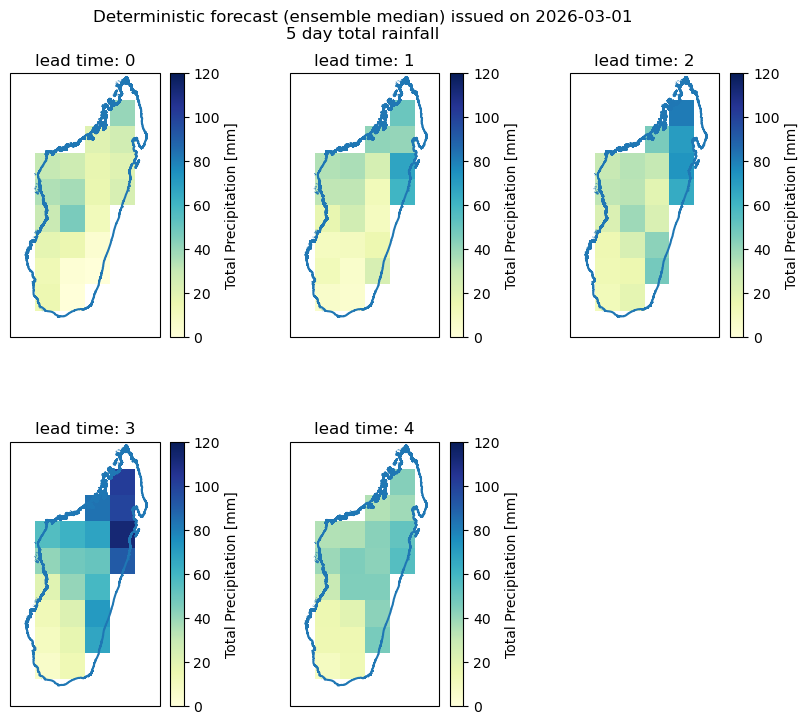

In [8]:
# we can now plot our results for each lead time

#reading overlay layer to add to plots
overlay=gpd.read_file(domain_shape_file)


#plotting forecast value

fig=plt.figure(figsize=(10,8))

for lead_time in range(5):
    pl=fig.add_subplot(2,3,lead_time+1, projection=ccrs.PlateCarree())
    forecast_det.isel(lead_time=lead_time).plot(cmap=plt.cm.YlGnBu, vmin=0, vmax=120)
    #adding overlay
    overlay.boundary.plot(ax=pl)
    pl.set_title("lead time: {}".format(lead_time))
    
plt.subplots_adjust(hspace=0.4, wspace=0.3, top=0.9)
plt.suptitle("Deterministic forecast (ensemble median) issued on {}\n{} day total rainfall".format(nominal_date, agg_window[:-1]))

Text(0.5, 0.98, 'Observed climatology for forecast issued on 2026-03-01\n5 day total rainfall')

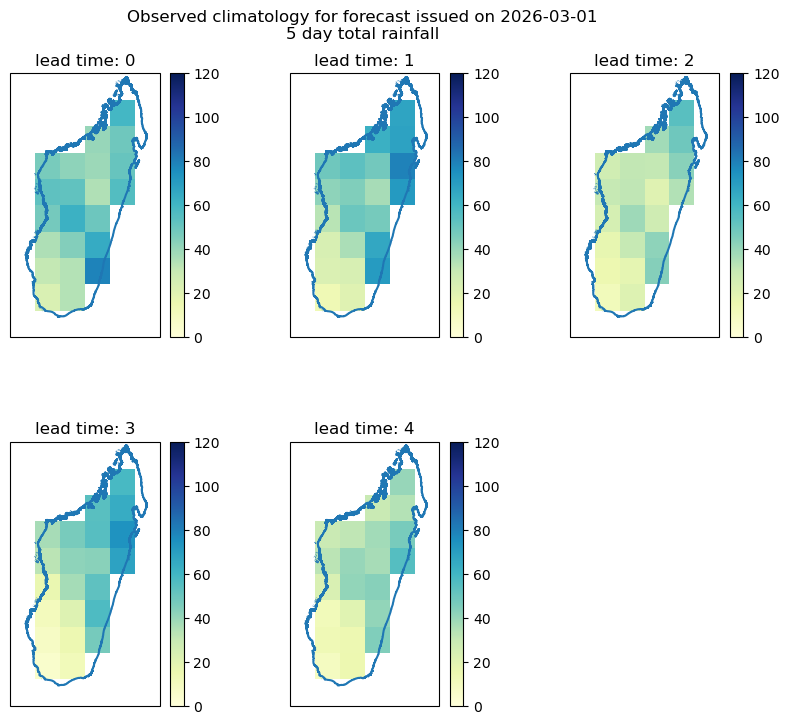

In [9]:
#plotting climatological value

fig=plt.figure(figsize=(10,8))

for lead_time in range(5):
    pl=fig.add_subplot(2,3,lead_time+1, projection=ccrs.PlateCarree())
    obs_clim.isel(lead_time=lead_time).plot(cmap=plt.cm.YlGnBu, vmin=0, vmax=120)
    #adding overlay
    overlay.boundary.plot(ax=pl)
    pl.set_title("lead time: {}".format(lead_time))
    
plt.subplots_adjust(hspace=0.4, wspace=0.3, top=0.9)
plt.suptitle("Observed climatology for forecast issued on {}\n{} day total rainfall".format(nominal_date, agg_window[:-1]))

Text(0.5, 0.98, 'Absolute anomaly forecast on 2026-03-01\n5 day total rainfall')

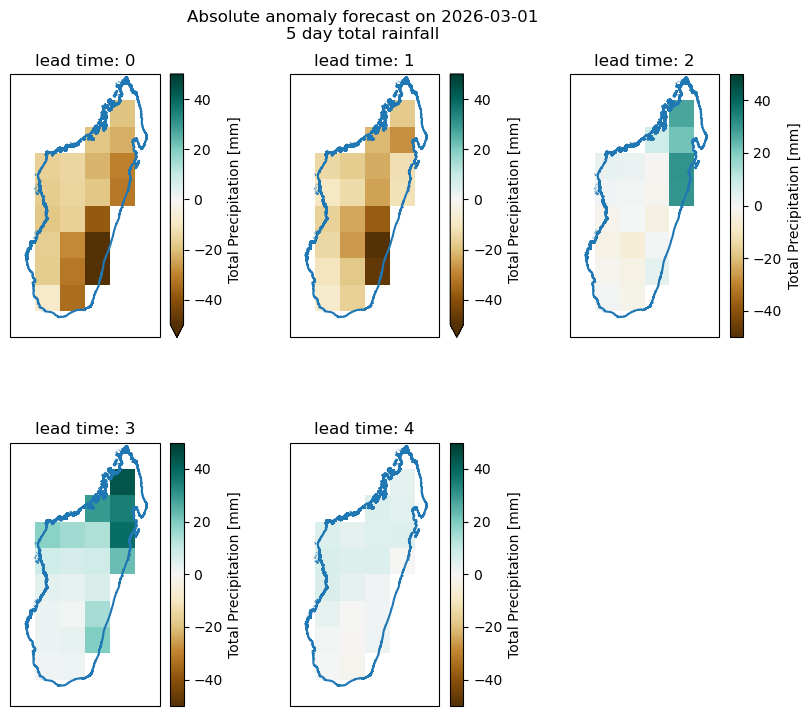

In [10]:
#plotting absolute anomaly

fig=plt.figure(figsize=(10,8))

for lead_time in range(5):
    pl=fig.add_subplot(2,3,lead_time+1, projection=ccrs.PlateCarree())
    forecast_absanom.isel(lead_time=lead_time).plot(cmap=plt.cm.BrBG, vmin=-50, vmax=50)
    #adding overlay
    overlay.boundary.plot(ax=pl)
    pl.set_title("lead time: {}".format(lead_time))
    
plt.subplots_adjust(hspace=0.4, wspace=0.3, top=0.9)
plt.suptitle("Absolute anomaly forecast on {}\n{} day total rainfall".format(nominal_date, agg_window[:-1]))

Text(0.5, 0.98, 'Relative anomaly forecast on 2026-03-01\n5 day total rainfall')

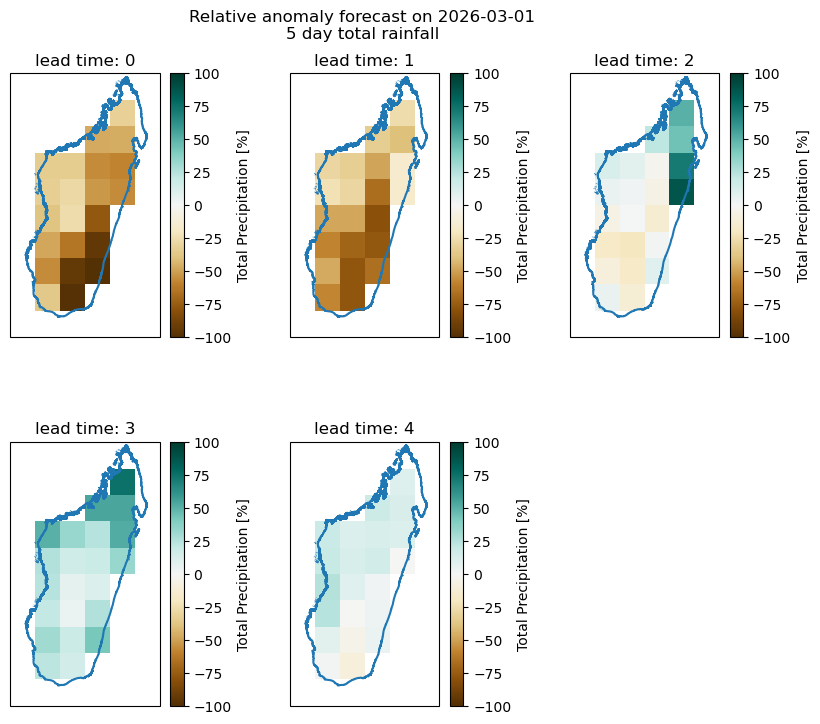

In [11]:
#plotting relative anomaly

fig=plt.figure(figsize=(10,8))

for lead_time in range(5):
    pl=fig.add_subplot(2,3,lead_time+1, projection=ccrs.PlateCarree())
    forecast_relanom.isel(lead_time=lead_time).plot(cmap=plt.cm.BrBG, vmin=-100, vmax=100)
    #adding overlay
    overlay.boundary.plot(ax=pl)
    pl.set_title("lead time: {}".format(lead_time))
    
plt.subplots_adjust(hspace=0.4, wspace=0.3, top=0.9)
plt.suptitle("Relative anomaly forecast on {}\n{} day total rainfall".format(nominal_date, agg_window[:-1]))

Text(0.5, 0.98, 'Percent normal anomaly forecast on 2026-03-01\n5 day total rainfall')

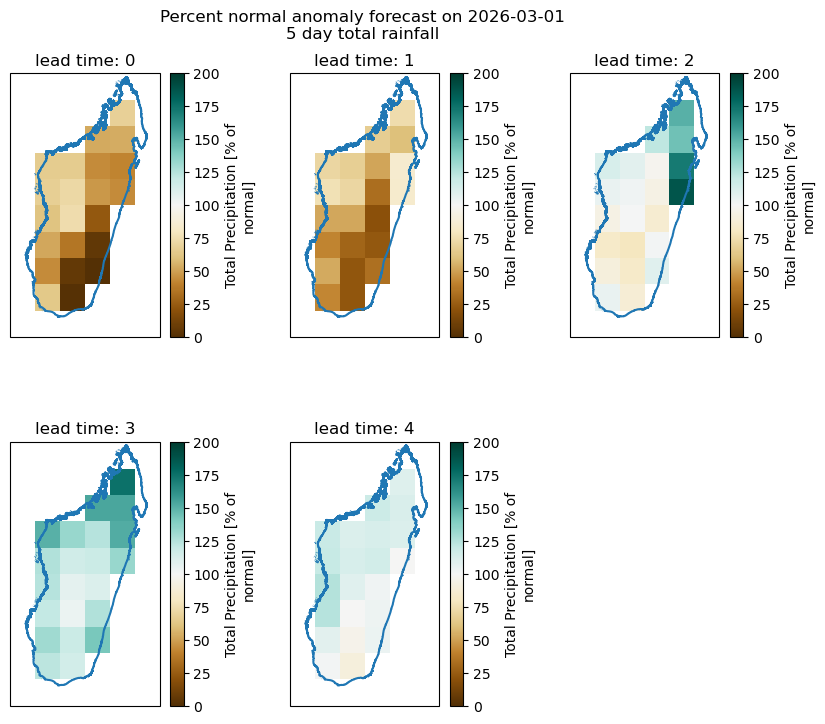

In [12]:
#plotting percent normal anomaly

fig=plt.figure(figsize=(10,8))

for lead_time in range(5):
    pl=fig.add_subplot(2,3,lead_time+1, projection=ccrs.PlateCarree())
    forecast_percanom.isel(lead_time=lead_time).plot(cmap=plt.cm.BrBG, vmin=0, vmax=200)
    #adding overlay
    overlay.boundary.plot(ax=pl)
    pl.set_title("lead time: {}".format(lead_time))
    
plt.subplots_adjust(hspace=0.4, wspace=0.3, top=0.9)
plt.suptitle("Percent normal anomaly forecast on {}\n{} day total rainfall".format(nominal_date, agg_window[:-1]))

## visualizing time series of forecast and hindcast

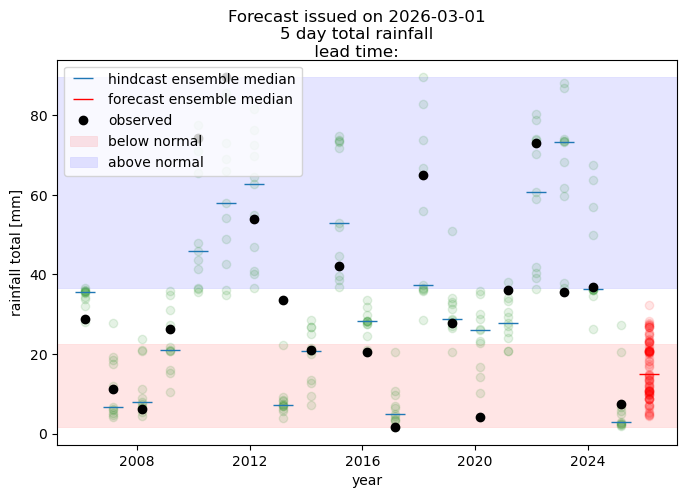

In [13]:
# time series can be visualized for a selected location or for average over a domain or a sub-region

# here we will use a location
lat,lon=-19,47.5

#we will plot it for a selected lead time
lead_time=0


# we use bias corrected forecast
hcst=hindcast_bc.sel(lead_time=lead_time, lat=lat, lon=lon, method="nearest")
fcst=forecast_bc.sel(lead_time=lead_time, lat=lat, lon=lon, method="nearest")

#and observations in the lead-time oriented format
obs=obs_lt.sel(lead_time=lead_time, lat=lat, lon=lon, method="nearest")


#now plotting
fig=plt.figure(figsize=(8,5))

pl=fig.add_subplot(1,1,1)

#plotting hincasts - individual members
for m in hcst.member:
    pl.plot(hcst.init_date,hcst.sel(member=m), "o", color="green", alpha=0.1)

#and hindcast median
pl.plot(hcst.init_date, hcst.median("member"), "_", ms=15, label="hindcast ensemble median")


#plotting forecast - individual members
for m in fcst.member:
    cont=True
    pl.plot(fcst.init_date,fcst.sel(member=m), "o", color="red",alpha=0.1)

pl.plot(fcst.init_date,fcst.median("member"), "_", color="red", ms=15, label="forecast ensemble median")

#plotting observations
pl.plot(obs.init_date,obs, "o", color="black", label="observed")

#adding terciles
pl.axhspan(obs.quantile(0.0), obs.quantile(0.33), label="below normal", color="red", alpha=0.1, lw=0.5)
pl.axhspan(obs.quantile(0.66), obs.quantile(1), label="above normal", color="blue", alpha=0.1, lw=0.5)


plt.suptitle("Forecast issued on {}\n{} day total rainfall\n lead time: ".format(nominal_date, agg_window[:-1], lead_time))

pl.set_xlabel("year")
pl.set_ylabel("rainfall total [mm]")
plt.legend()
plt.show()